# Wafer Defect Detection with an Artificial Neural Network

In `simple-mlp.ipynb` we built a small neural network from scratch so every weight update was visible. Here we use scikit-learn's `MLPClassifier` for an applied manufacturing problem: flagging wafers that are likely to be bad from hundreds of in-line sensor readings.

The dataset in this notebook is `wafer_synthetic_10000.csv`: 10,000 synthetic wafers generated in `synthetic-data-generation.ipynb` from a real 100-row wafer dataset. That generator learned the real data's marginal distributions, correlations, PCA structure, and label pattern, then sampled a larger teaching dataset. It is useful for practice, but it is still synthetic and should not be treated as real fab economics or production evidence.

### Learning objectives

By the end of this notebook you should be able to:

- Explain why wafer fabrication naturally produces hundreds of correlated sensor readings per wafer.
- Frame wafer quality prediction as an imbalanced binary classification problem.
- Build a reproducible train/validation/test workflow without leaking information from validation or test data into preprocessing.
- Tune an ANN with Optuna Bayesian search, L2 regularization, and an imbalance-aware scoring metric.
- Read accuracy, precision, recall, F1, ROC-AUC, and a confusion matrix in a business context.

### Imports and reproducibility

All imports for this notebook live in the cell below. We use NumPy and pandas for data handling, matplotlib for figures, and scikit-learn for preprocessing, model selection, and the ANN implementation.

In [1]:
# --- All imports for this notebook live here ---
import importlib.util
import os
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optuna powers the Bayesian hyperparameter search below. It is not part of the
# standard Colab image, so install it on the fly if it is missing.
if importlib.util.find_spec("optuna") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "optuna"], check=True)
import optuna

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

np.random.seed(0)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

CSV = "wafer_synthetic_10000.csv"

# Colab: this notebook may be opened without the repo's data files.
# Fetch the dataset on demand so it runs anywhere.
import os
import urllib.request
_RAW = "https://raw.githubusercontent.com/IIB-Lab/AI-ML-bootcamp-tutorials/main/04-deep-learning/mlp/"
if not os.path.exists(CSV):
    print(f"downloading {CSV} ...")
    urllib.request.urlretrieve(_RAW + CSV, CSV)

## 1. Wafer fabrication pipeline: why so many sensors?

A **wafer** is a thin silicon disk that goes through hundreds of tightly controlled processing steps before it becomes finished chips. A single row in this dataset summarizes one wafer after a processing history, but the `Sensor-*` columns are not mapped to named stages. We therefore should not say `Sensor-17` is an etch pressure or `Sensor-210` is a CMP reading. What we can say is that a fab process naturally creates many correlated process measurements.

**Deposition.** Deposition steps add very thin films to the wafer surface, often only a few atoms to a few micrometers thick. Tools monitor variables such as chamber temperature, pressure, gas flow rates, plasma power, deposition time, and recipe identifiers because small changes can alter film thickness and material properties.

**Photolithography.** Lithography transfers a circuit pattern onto the wafer using photoresist, masks, light exposure, and development. Sensors and logs can record resist thickness, bake temperatures, exposure dose, focus, alignment, track time, humidity, and tool/chamber information.

**Etch.** Etch steps remove selected material where the pattern exposes it. Dry plasma etch tools may track gas chemistry, pressure, RF power, endpoint signals, time, and chamber state; wet etch tools may track bath temperature, concentration, and dwell time.

**Ion implantation and diffusion.** These steps introduce dopant atoms that change the electrical behavior of silicon. The process may log beam current, dose, energy, angle, temperature, anneal time, and recipe settings.

**Chemical-mechanical planarization (CMP).** CMP polishes the wafer surface flat so later layers can be patterned reliably. Tools may track platen speed, downforce, slurry flow, pad condition, polish time, and post-clean measurements.

**Metrology and inspection.** Between processing steps, metrology tools measure whether the wafer is still within specification. They may record film thickness, critical dimensions, overlay error, defect counts, reflectance, and other quality checks.

Each stage has multiple in-line sensors and recipe logs. Across many stages, those measurements quickly add up to hundreds of columns for a single wafer.

<img src="https://raw.githubusercontent.com/IIB-Lab/AI-ML-bootcamp-tutorials/main/04-deep-learning/mlp/images/02_wafer-defect-detection-ann-fig1.png" alt="02_wafer-defect-detection-ann figure 1" width="920">

**Reading:** The wafer follows a physical route through the fab, but the data row is a log of many measurements collected along that route. The high feature count is not surprising: many stages times many sensors per stage gives hundreds of correlated readings.

## 2. Framing the ML problem

The predictors are the sensor readings:

$$
X = [\text{Sensor-1}, \text{Sensor-2}, \dots, \text{Sensor-590}]
$$

The target is `Good/Bad`, where `-1` means a good wafer and `1` means a bad wafer. We recode this target as `0 = good` and `1 = bad`, so the positive class is the failure class we want to catch.

This is a **binary classification** problem, but it is not a balanced one. Only about 5% of wafers are bad. A classifier that calls every wafer good would have about 95% accuracy and be useless for quality control. For this reason we will track **precision**, **recall**, **F1**, **ROC-AUC**, and average precision instead of trusting accuracy alone. In this setting, missing a bad wafer can be much more expensive than false-alarming a good one.

In [2]:
df = pd.read_csv(CSV)

id_col = "Unnamed: 0"
target_col = "Good/Bad"
sensor_cols = [c for c in df.columns if c.startswith("Sensor-")]

constant_sensors = df[sensor_cols].columns[df[sensor_cols].nunique(dropna=False) <= 1].tolist()
feature_cols = [c for c in sensor_cols if c not in constant_sensors]

X = df[feature_cols].copy()
y = (df[target_col] == 1).astype(int)
wafer_id = df[id_col].copy()

print(f"raw data: {df.shape[0]:,} wafers x {len(sensor_cols):,} sensor columns")
print(f"dropped {len(constant_sensors):,} truly constant sensors")
print(f"model features: {X.shape[1]:,} non-constant sensor columns")
print(f"positive class: {y.sum():,} bad wafers ({y.mean():.1%})")

raw data: 10,000 wafers x 590 sensor columns
dropped 122 truly constant sensors
model features: 468 non-constant sensor columns
positive class: 505 bad wafers (5.1%)


In [3]:
X_train, X_temp, y_train, y_temp, id_train, id_temp = train_test_split(
    X, y, wafer_id, test_size=0.40, stratify=y, random_state=0
)
X_val, X_test, y_val, y_test, id_val, id_test = train_test_split(
    X_temp, y_temp, id_temp, test_size=0.50, stratify=y_temp, random_state=0
)

split_counts = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "bad_wafers": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
})
split_counts["bad_rate"] = split_counts["bad_wafers"] / split_counts["rows"]
split_counts

,split,rows,bad_wafers,bad_rate
0,train,6000,303,0.0505
1,validation,2000,101,0.0505
2,test,2000,101,0.0505


In [4]:
# Let's see how the data look like first.

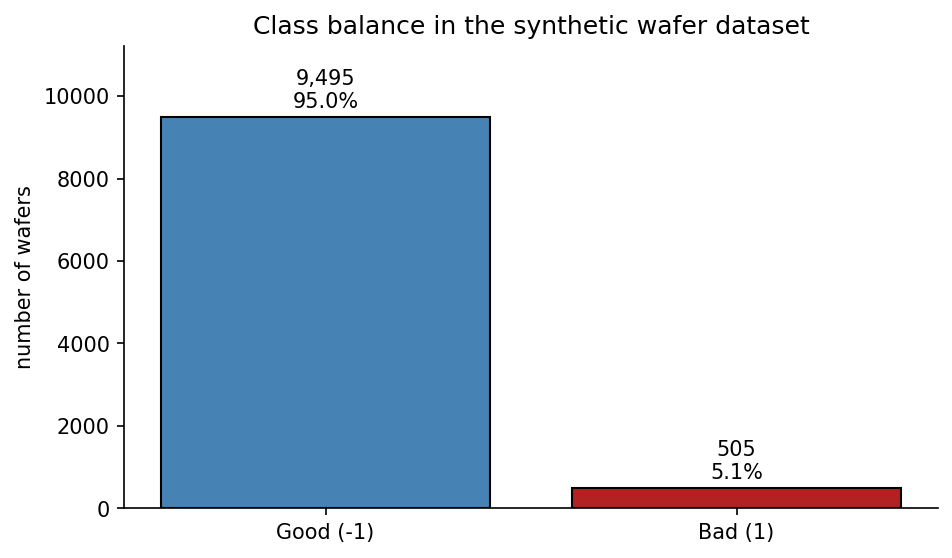

In [6]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
labels = ["Good (-1)", "Bad (1)"]
counts = [(y == 0).sum(), (y == 1).sum()]
bars = ax.bar(labels, counts, color=["steelblue", "firebrick"], edgecolor="black")
ax.set_ylabel("number of wafers")
ax.set_title("Class balance in the synthetic wafer dataset")
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 120,
        f"{count:,}\n{count / len(y):.1%}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set_ylim(0, max(counts) * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

**Reading:** The bad class is small but important. Accuracy will be dominated by the many good wafers, so we need metrics that focus on the positive class.

## 3. Train an ANN with hyperparameter tuning and regularization

The from-scratch notebook showed the mechanics of neurons, forward passes, backpropagation, and gradient descent. Here scikit-learn's `MLPClassifier` wraps those mechanics in a reusable estimator. The main modeling choices we tune are `hidden_layer_sizes`, which controls one or more hidden layers, and `alpha`, which applies L2 weight-decay regularization to discourage overly large weights.

A grid search would try every combination on a fixed grid and could only test the exact `alpha` values we list. Instead we use **Optuna** with a **TPE (Tree-structured Parzen Estimator) sampler** -- a Bayesian optimizer that models which hyperparameter regions have scored well and preferentially samples there. It reaches a strong configuration in fewer trials and searches `alpha` over a continuous, log-scaled range rather than a handful of fixed values. Optuna also chooses the network's depth (1-4 hidden layers) and each layer's width (16-512 neurons), not just a fixed list of shapes.

Each trial trains on the training split and is scored on the **validation split** with **average precision** — exactly the role the validation set exists for. Average precision summarizes the precision-recall curve and is more informative than accuracy when the positive class is rare. (A k-fold cross-validation would give a lower-variance estimate at k times the training cost; with 6,000 training rows and a validation set this size, a single hold-out score is enough to rank configurations and keeps the notebook fast.) The held-out test set remains untouched until the final report.

Before the network sees them, the sensor columns are compressed by **PCA** to a handful of principal components. That keeps the problem light enough to run comfortably on Colab, and — because the PCA step sits *inside* the pipeline — it is fitted on the training rows only, so no information leaks in from validation or test. Note this is a genuine modelling step, unlike the 2-D PCA in Section 2 which was only a picture.

In [7]:
# We tune scikit-learn's MLPClassifier with Optuna instead of an exhaustive grid.
# Optuna's TPE sampler is a Bayesian optimizer: it models which regions of the search
# space have scored well and preferentially samples there, finding a strong config in
# fewer trials. Here it chooses the DEPTH (1-4 hidden layers), each layer's WIDTH
# (16-512 neurons, in steps of 16), and the L2 strength alpha over a continuous log range.
# Each trial trains once on the training split and is scored on the validation split.

# Colab-friendly dimensionality reduction: compress the sensor columns down to a handful
# of principal components. PCA lives INSIDE the pipeline, so it is fitted on the training
# rows only -- fitting it once on all the data would leak validation/test information.
N_COMPONENTS = 30
_probe = PCA(n_components=N_COMPONENTS, random_state=0).fit(StandardScaler().fit_transform(X_train))
print(f"{X_train.shape[1]} sensors -> {N_COMPONENTS} principal components, retaining "
      f"{_probe.explained_variance_ratio_.sum():.1%} of the sensor variance")


def make_pipeline(hidden_layer_sizes, alpha):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_COMPONENTS, random_state=0)),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes, alpha=alpha,
            solver="adam", max_iter=120, batch_size=256, learning_rate_init=0.001,
            early_stopping=True, validation_fraction=0.15, n_iter_no_change=8,
            random_state=0,
        )),
    ])

def suggest_architecture(trial):
    n_layers = trial.suggest_int("n_layers", 1, 4)
    return tuple(trial.suggest_int(f"n_units_l{i}", 16, 512, step=16)
                 for i in range(n_layers))

def objective(trial):
    hidden = suggest_architecture(trial)
    alpha = trial.suggest_float("alpha", 1e-5, 1e-1, log=True)
    pipe = make_pipeline(hidden, alpha).fit(X_train, y_train)
    return average_precision_score(y_val, pipe.predict_proba(X_val)[:, 1])

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(objective, n_trials=10, show_progress_bar=True)

bp = study.best_params
best_hidden = tuple(bp[f"n_units_l{i}"] for i in range(bp["n_layers"]))
best_alpha = bp["alpha"]
best_estimator = make_pipeline(best_hidden, best_alpha).fit(X_train, y_train)

print("best architecture:", best_hidden, "| alpha:", best_alpha)
print(f"best validation average precision: {study.best_value:.3f}")

468 sensors -> 30 principal components, retaining 63.2% of the sensor variance


  0%|          | 0/10 [00:00<?, ?it/s]

best architecture: (400, 240) | alpha: 0.001878173875716191
best validation average precision: 0.127


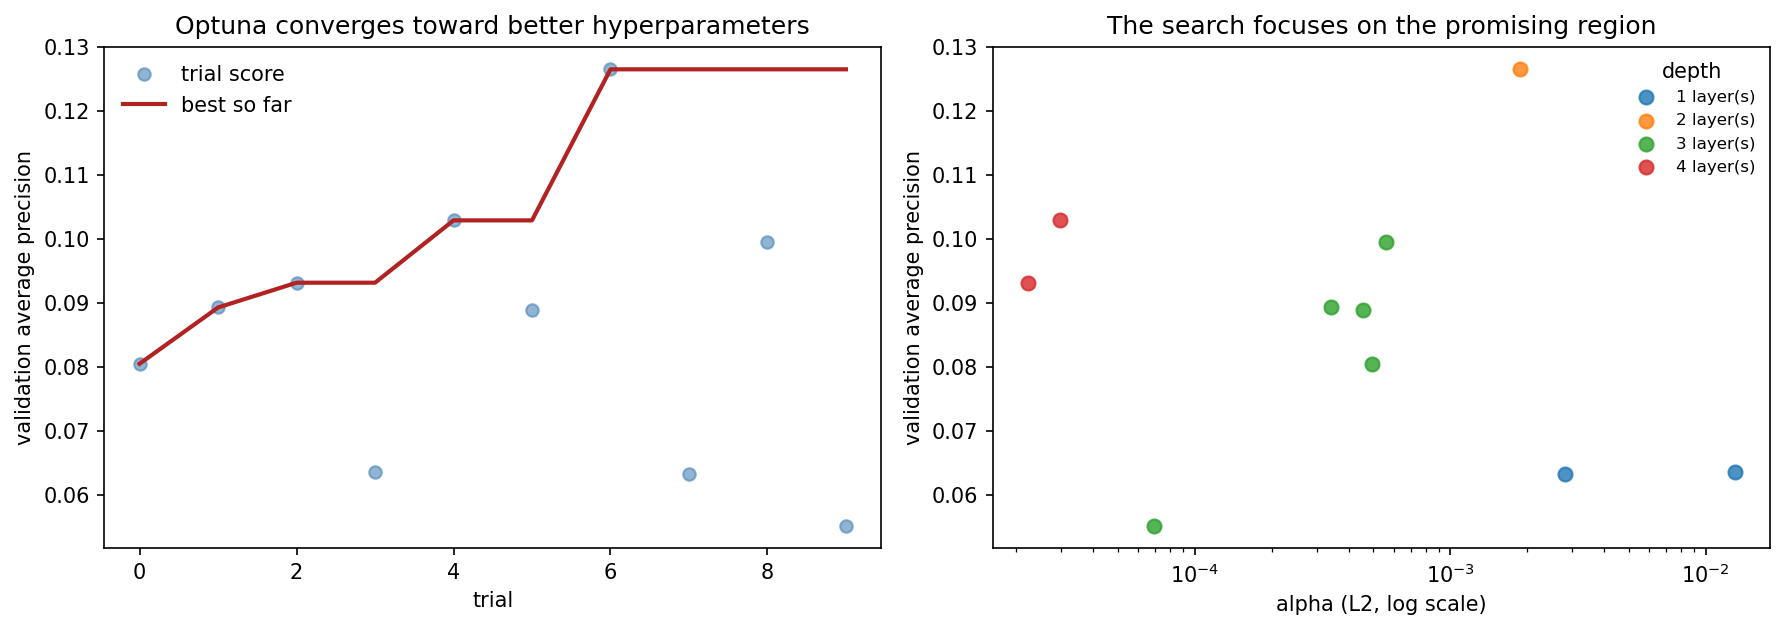

best trial: 6 -> architecture (400, 240) alpha 0.00188


In [8]:
trials = study.trials_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), dpi=150)
# (a) optimization history: each trial's score and the running best
axes[0].plot(trials["number"], trials["value"], "o", color="steelblue", alpha=0.6, label="trial score")
axes[0].plot(trials["number"], trials["value"].cummax(), color="firebrick", lw=2, label="best so far")
axes[0].set_xlabel("trial"); axes[0].set_ylabel("validation average precision")
axes[0].set_title("Optuna converges toward better hyperparameters")
axes[0].legend(frameon=False)

# (b) where it sampled: alpha (log) vs score, colored by network depth
for nl in sorted(trials["params_n_layers"].dropna().unique()):
    m = trials["params_n_layers"] == nl
    axes[1].scatter(trials.loc[m, "params_alpha"], trials.loc[m, "value"],
                    s=45, alpha=0.8, label=f"{int(nl)} layer(s)")
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha (L2, log scale)"); axes[1].set_ylabel("validation average precision")
axes[1].set_title("The search focuses on the promising region")
axes[1].legend(frameon=False, title="depth", fontsize=8)
plt.tight_layout(); plt.show()

print("best trial:", study.best_trial.number, "-> architecture", best_hidden, "alpha", round(best_alpha, 5))

**Reading:** The scores are modest because the positive class is rare and the synthetic labels overlap the good-wafer patterns. The optimization-history plot shows the running best climbing as Optuna concentrates its trials, and the sampling plot shows it favoring the promising `alpha` region. The best configuration is selected by average precision, not by accuracy, so the search favors models that rank bad wafers higher in the probability list.

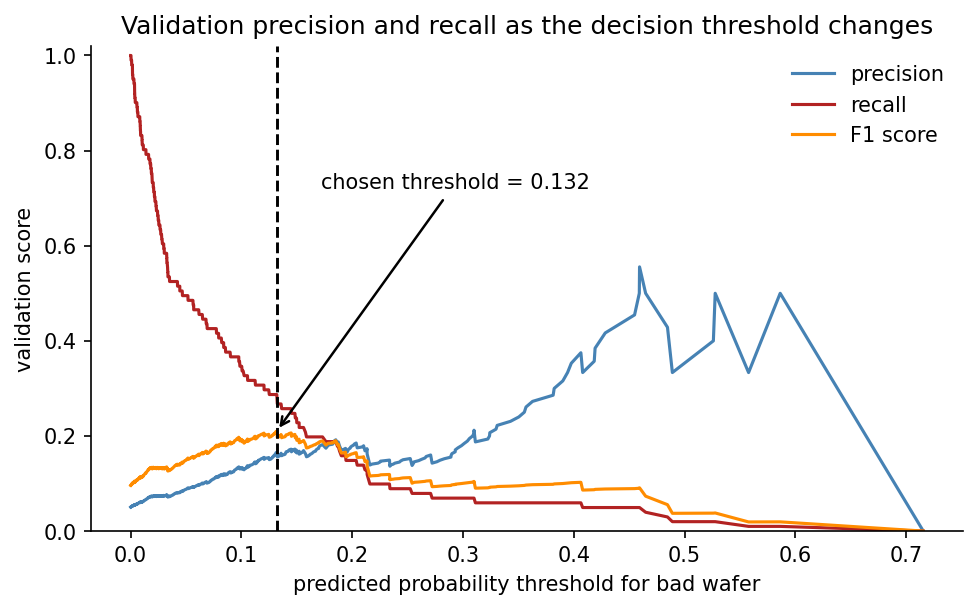

validation-selected threshold: 0.132
validation precision: 0.166
validation recall: 0.287
validation F1: 0.210


In [10]:
val_proba = best_estimator.predict_proba(X_val)[:, 1]
val_precision, val_recall, val_thresholds = precision_recall_curve(y_val, val_proba)
val_f1 = 2 * val_precision[:-1] * val_recall[:-1] / (val_precision[:-1] + val_recall[:-1] + 1e-12)
best_threshold_idx = int(np.argmax(val_f1))
decision_threshold = float(val_thresholds[best_threshold_idx])

fig, ax = plt.subplots(figsize=(7.5, 4.2), dpi=150)
ax.plot(val_thresholds, val_precision[:-1], color="steelblue", label="precision")
ax.plot(val_thresholds, val_recall[:-1], color="firebrick", label="recall")
ax.plot(val_thresholds, val_f1, color="darkorange", label="F1 score")
ax.axvline(decision_threshold, color="black", linestyle="--", linewidth=1.4)
ax.annotate(
    f"chosen threshold = {decision_threshold:.3f}",
    xy=(decision_threshold, val_f1[best_threshold_idx]),
    xytext=(decision_threshold + 0.04, 0.72),
    arrowprops={"arrowstyle": "->", "color": "black", "lw": 1.2},
)
ax.set_xlabel("predicted probability threshold for bad wafer")
ax.set_ylabel("validation score")
ax.set_title("Validation precision and recall as the decision threshold changes")
ax.set_ylim(0, 1.02)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

print(f"validation-selected threshold: {decision_threshold:.3f}")
print(f"validation precision: {val_precision[best_threshold_idx]:.3f}")
print(f"validation recall: {val_recall[best_threshold_idx]:.3f}")
print(f"validation F1: {val_f1[best_threshold_idx]:.3f}")

**Reading:** The usual `0.5` cutoff is often too high for rare-event problems. Lowering the threshold catches more bad wafers, but it also flags more good wafers. We choose the threshold on validation data only; the test set is still untouched.

In [11]:
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

final_model = clone(best_estimator)
final_model.fit(X_trainval, y_trainval)

test_proba = final_model.predict_proba(X_test)[:, 1]
y_pred = (test_proba >= decision_threshold).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, test_proba),
    "average_precision": average_precision_score(y_test, test_proba),
}

pd.DataFrame(metrics, index=["test"]).T.rename(columns={"test": "score"})

,score
accuracy,0.919000
precision,0.178947
recall,0.168317
F1,0.173469
ROC-AUC,0.680400
average_precision,0.118933


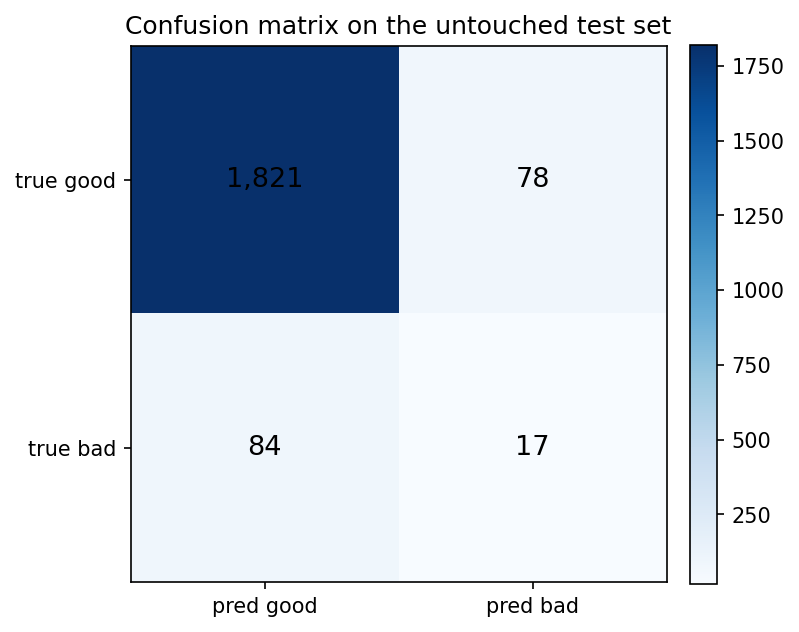

test accuracy:  0.919
test precision: 0.179
test recall:    0.168
test F1:        0.173
test ROC-AUC:   0.680


In [12]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5.2, 4.5), dpi=150)
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["pred good", "pred bad"])
ax.set_yticklabels(["true good", "true bad"])
ax.set_title("Confusion matrix on the untouched test set")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=13, color="black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print(f"test accuracy:  {metrics['accuracy']:.3f}")
print(f"test precision: {metrics['precision']:.3f}")
print(f"test recall:    {metrics['recall']:.3f}")
print(f"test F1:        {metrics['F1']:.3f}")
print(f"test ROC-AUC:   {metrics['ROC-AUC']:.3f}")

In [13]:
# Are those numbers any good? Compare the tuned ANN to two trivial baselines on the
# SAME test set: a proportional-random predictor (flags wafers at the base rate, no
# signal) and an always-good predictor (never flags anything).
baselines = {
    "proportional-random": DummyClassifier(strategy="stratified", random_state=0),
    "always-good": DummyClassifier(strategy="most_frequent"),
}

def score_row(proba, pred):
    return {
        "average_precision": average_precision_score(y_test, proba),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "accuracy": accuracy_score(y_test, pred),
    }

comparison = {"tuned ANN": score_row(test_proba, y_pred)}
for name, model in baselines.items():
    model.fit(X_trainval, y_trainval)
    comparison[name] = score_row(model.predict_proba(X_test)[:, 1], model.predict(X_test))

print(f"test-set base rate (bad wafers): {y_test.mean():.3f}  ->  a no-signal classifier "
      f"scores ROC-AUC ~0.5 and average_precision ~{y_test.mean():.3f}")
pd.DataFrame(comparison).T.round(3)

test-set base rate (bad wafers): 0.051  ->  a no-signal classifier scores ROC-AUC ~0.5 and average_precision ~0.051


,average_precision,ROC-AUC,precision,recall,F1,accuracy
tuned ANN,0.119,0.680,0.179,0.168,0.173,0.919
proportional-random,0.053,0.515,0.073,0.089,0.080,0.897
always-good,0.050,0.500,0.000,0.000,0.000,0.950


**Reading — is the model actually learning?** Against a **proportional-random** predictor and an **always-good** predictor, the tuned ANN wins on every *signal* metric: its **average precision is ~1.8x the random floor** (which equals the base rate) and its **ROC-AUC sits well above 0.5**. So the network has learned real structure — modest but genuine, about what this faint, heavily-overlapping synthetic data allows.

But notice the last column: **accuracy is a trap here.** The "always-good" predictor posts the *highest* accuracy of the three by never flagging a single wafer — while catching zero defects. On a rare-event problem you must judge the model by average precision, ROC-AUC, recall, and F1, and ignore raw accuracy.

**Takeaway:** Recall answers, "Of the bad wafers, how many did we catch?" Precision answers, "Of the wafers we flagged, how many were really bad?" In a fab setting, a missed bad wafer may keep consuming expensive downstream process time, while a false alarm may trigger review, rework, or temporary hold on a good wafer. The right threshold is therefore a business decision, not just a mathematical default.

## 4. How the model is used in practice

In production, the model would not just report a test-set metric. A batch of wafers finishes a process stage, the sensor row is standardized with the same train-fitted scaler, and the ANN outputs a probability that each wafer is bad. Wafers above the chosen threshold can be held for early scrap, rework, or engineering review instead of continuing blindly through the rest of the fab process.

## Summary

- Wafer fabrication produces many sensor readings because each physical stage logs multiple process, recipe, chamber, and inspection variables.
- The predictors are non-constant `Sensor-*` columns; the target is `Good/Bad`, recoded as `1 = bad` and `0 = good`.
- The data are imbalanced: about 5% of wafers are bad, so accuracy alone is a poor guide.
- A train/validation/test split protects the final test set, while train-fitted scaling avoids preprocessing leakage.
- `MLPClassifier` extends the from-scratch MLP idea to an applied setting with multiple hidden layers, L2 regularization, and early stopping.
- A deployed model uses probabilities and a decision threshold to support early scrap, rework, or engineering review decisions.

## Exercises

1. **Change the search score.** In `objective`, replace `average_precision_score` with `roc_auc_score` (or score the thresholded predictions with `f1_score`) and re-run `study.optimize`. Does it choose the same hidden layer sizes and `alpha`?

### What is the ROC curve, and what does AUC measure?

Precision, recall, and F1 each describe the model at **one** threshold. But the network never outputs a decision — it outputs a *probability*, and we choose where to cut. Move the cut and all three numbers move with it. The **ROC curve** is what you get when you refuse to pick: sweep the threshold from 1 down to 0 and plot, at every step, how many bad wafers you caught (**true positive rate**) against how many good wafers you wrongly flagged (**false positive rate**).

<img src="https://raw.githubusercontent.com/IIB-Lab/AI-ML-bootcamp-tutorials/main/04-deep-learning/mlp/images/02_wafer-defect-detection-ann-fig2.png" alt="ROC curve: true positive rate against false positive rate, with the area under the curve shaded as AUC and a dashed chance diagonal." width="900">

**Reading the curve.** Both endpoints are forced and tell you nothing about the model: at threshold 1 you flag no wafers at all (catch nothing, false-alarm no one — bottom left), and at threshold 0 you flag every wafer (catch everything, false-alarm everyone — top right). Every classifier ever built passes through those two corners. All the information lives in the shape *between* them. A curve that bulges toward the **top-left corner** is a model that catches many bad wafers while flagging few good ones. The **dashed diagonal** is a model with no signal at all: to catch 40% of the bad wafers it must also flag 40% of the good ones, which is what a coin flip does.

**AUC** — computed by `roc_auc_score`, and reported as `ROC-AUC` in the tables above — is the shaded area under that curve. Its real interpretation has nothing to do with areas:

> Pick one bad wafer and one good wafer at random. **AUC is the probability that the model gives the bad one the higher score.**

So AUC measures **ranking quality**, not accuracy, and it does not depend on which threshold you eventually deploy. That is why it can be computed straight from `predict_proba` without choosing a cutoff. Our tuned ANN scores **0.680** on the test set: shown a random bad/good pair, it ranks the bad wafer higher about 68% of the time. Clearly above the 0.5 coin flip — the network has learned something real — and just as clearly far from a solved problem.

**Why we tuned on average precision instead.** ROC-AUC averages performance across *every* threshold, including ones no fab would ever run — the far right of the curve, where you have halted most of the line. Because 95% of these wafers are good, the model can shuffle thousands of good wafers around the middle of its ranking, barely move the ROC curve, and still destroy the precision among the handful of wafers it flags most confidently. The precision-recall curve and its area (**average precision**) ignore the true negatives entirely and look only at the top of the ranking — the wafers you would actually pull for review.

That is exactly what the exercise above asks you to test, and the cell below measures it: search on ROC-AUC instead of average precision, and see what the swap costs.

In [14]:
# Same search space, same sampler seed, same 10 trials -- only the scored metric changes.
def objective_auc(trial):
    hidden = suggest_architecture(trial)
    alpha = trial.suggest_float("alpha", 1e-5, 1e-1, log=True)
    pipe = make_pipeline(hidden, alpha).fit(X_train, y_train)
    return roc_auc_score(y_val, pipe.predict_proba(X_val)[:, 1])   # <- was average_precision_score

study_auc = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=0))
study_auc.optimize(objective_auc, n_trials=10, show_progress_bar=True)

bp_auc = study_auc.best_params
auc_hidden = tuple(bp_auc[f"n_units_l{i}"] for i in range(bp_auc["n_layers"]))
auc_alpha = bp_auc["alpha"]
auc_estimator = make_pipeline(auc_hidden, auc_alpha).fit(X_train, y_train)

# Judge each winner on BOTH metrics, on the same validation rows.
rows = {}
for name, model, hidden, alpha in [
    ("tuned for average precision", best_estimator, best_hidden, best_alpha),
    ("tuned for ROC-AUC", auc_estimator, auc_hidden, auc_alpha),
]:
    proba = model.predict_proba(X_val)[:, 1]
    rows[name] = {
        "architecture": str(hidden),
        "alpha": round(alpha, 5),
        "val average precision": round(average_precision_score(y_val, proba), 4),
        "val ROC-AUC": round(roc_auc_score(y_val, proba), 4),
    }

pd.DataFrame(rows).T

  0%|          | 0/10 [00:00<?, ?it/s]

,architecture,alpha,val average precision,val ROC-AUC
tuned for average precision,"(400, 240)",0.00188,0.1265,0.6631
tuned for ROC-AUC,"(512, 416, 240, 400)",0.00003,0.1029,0.6672


## References

- Course notebook: `04-deep-learning/mlp/simple-mlp.ipynb`.
- Course notebook: `04-deep-learning/mlp/synthetic-data-generation.ipynb`.
- scikit-learn documentation: `MLPClassifier` and classification metrics; Optuna documentation for the TPE sampler.
- Nielsen, *Neural Networks and Deep Learning* - http://neuralnetworksanddeeplearning.com/